## 1 . Install party

In [25]:
from __future__ import annotations
from dataclasses import dataclass, field, replace
from collections import defaultdict, Counter
from itertools import combinations, product
from types import MappingProxyType
from pathlib import Path
import json
import math
import random
import time
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from IPython.display import display, Markdown

try:
    import cvxpy as cp
except ImportError:
    cp = None

try:
    import gcol
except ImportError:
    gcol = None


## 2 . Experiment controls
- Availability: independent Bernoulli draw per teacher × slot.
- Desire: student opt-in probability; scores count requested external options.
- `desire_by_department`: per-dept overrides; `seed=None`: fresh random input.
- Budgets limit run time; a timeout ≠ infeasibility.

In [26]:
INSTALL_COMMAND = '%pip install networkx==3.6.1 matplotlib gcol==2.2 numpy scipy pandas cvxpy==1.7.5'

@dataclass
class ExperimentConfig:
    courses: int = 40
    max_department_size: int = 8
    teacher_reuse_probability: float = 0.35
    professor_availability_probability: float = 0.25
    cross_department_desire_probability: float = 0.35
    desire_by_department: dict = field(default_factory=dict)
    cohort_size: int = 60
    external_courses_per_student: int = 2
    external_course_offer_probability: float = 0.20
    seed: int | None = None
    generation_attempts: int = 80
    feasibility_timeout: float = 2.0
    feasibility_iterations: int = 1000
    local_rounds: int = 8
    pair_component_limit: int = 9
    use_newman: bool = True
    newman_rounds: int = 128
    repair_candidates: int = 3
    repair_timeout: float = 1.0
    sdp_solver: str = 'SCS'
    sdp_iterations: int = 12000
    run_parameter_sweep: bool = False

    def validate(self):
        for name in ['teacher_reuse_probability', 'professor_availability_probability',
                     'cross_department_desire_probability', 'external_course_offer_probability']:
            if not 0 <= getattr(self, name) <= 1:
                raise ValueError(f'{name} must be in [0,1]')
        if any(not 0 <= q <= 1 for q in self.desire_by_department.values()):
            raise ValueError('Department desire probabilities must be in [0,1]')
        for name in ['courses', 'max_department_size', 'cohort_size', 'external_courses_per_student',
                     'generation_attempts', 'newman_rounds', 'repair_candidates', 'local_rounds',
                     'sdp_iterations']:
            if not isinstance(getattr(self, name), int) or getattr(self, name) < 1:
                raise ValueError(f'{name} must be a positive integer')
        if self.feasibility_iterations < 0 or self.pair_component_limit < 0:
            raise ValueError('Search limits must be nonnegative')
        if self.feasibility_timeout <= 0 or self.repair_timeout <= 0:
            raise ValueError('Timeouts must be positive')
        return self

CONFIG = ExperimentConfig()

CONTROL_GUIDE = {
    'professor_availability_probability': 'Independent probability for each professor and weekly slot; zero availability is allowed in generated input.',
    'cross_department_desire_probability': 'Fraction of students seeking external courses; these students choose up to external_courses_per_student courses.',
    'desire_by_department': 'Overrides such as {"CS": 0.7, "MA": 0.2}.',
    'external_course_offer_probability': 'Probability an external course is a candidate option for a department.',
    'seed': 'None: fresh input on each run. Integer: reproducible random draws (runtime limits can still differ).',
    'use_newman': 'Enable SDP Max-k-Cut proposals, then feasibility repair. Its approximation ratio applies before repair.',
    'run_parameter_sweep': 'Enable a small experiment varying availability and desire; infeasible inputs and timeouts are counted separately.'
}
display(pd.DataFrame(CONTROL_GUIDE.items(), columns=['Control', 'Meaning']))

,Control,Meaning
0,professor_availability_probability,Independent probability for each professor and...
1,cross_department_desire_probability,Fraction of students seeking external courses;...
2,desire_by_department,"Overrides such as {""CS"": 0.7, ""MA"": 0.2}."
3,external_course_offer_probability,Probability an external course is a candidate ...
4,seed,None: fresh input on each run. Integer: reprod...
5,use_newman,"Enable SDP Max-k-Cut proposals, then feasibili..."
6,run_parameter_sweep,Enable a small experiment varying availability...


## 3 . Data + graphs
- Hard edge: same dept or teacher → different colors. Lists = teacher availability.
- Optional weight: `s(dept(u),v) + s(dept(v),u)`.
- Graphs cached; input maps read-only. Dept = cohort conflict group, not necessarily subject.

In [27]:
WEEKDAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
TIME_BLOCKS = [
    ("08:00", "09:00"),
    ("09:00", "10:00"),
    ("10:00", "11:00"),
    ("11:00", "12:00"),
    ("13:00", "14:00"),
    ("14:00", "15:00"),
    ("15:00", "16:00"),
    ("16:00", "17:00"),
]


def weekly_slot(day, block):
    if isinstance(day, str):
        day = WEEKDAYS.index(day)
    return len(TIME_BLOCKS) * day + block


def weekly_slot_labels():
    return {
        weekly_slot(d, b): f"{WEEKDAYS[d]} {start}–{end}"
        for d in range(5)
        for b, (start, end) in enumerate(TIME_BLOCKS)
    }


@dataclass(frozen=True)
class LinkConstraint:
    first: object
    second: object
    min_gap: int = 1
    max_gap: int | None = None
    same_day: bool = False


@dataclass
class TimetableInstance:
    T: int
    department: dict
    teacher: dict
    professor_availability: dict
    scores: dict
    slot_labels: dict | None = None
    links: tuple = ()
    slots_per_day: int = 8

    @property
    def classes(self):
        return list(self.department)

    @property
    def departments(self):
        return sorted(set(self.department.values()), key=str)

    @property
    def professors(self):
        return sorted(set(self.teacher.values()), key=str)

    def classes_of_department(self, A):
        return [v for v in self.classes if self.department[v] == A]

    def classes_of_professor(self, p):
        return [v for v in self.classes if self.teacher[v] == p]

    def allowed_slots(self, c):
        return set(self.professor_availability[self.teacher[c]])

    def slot_name(self, t):
        if self.slot_labels is None:
            return str(t)
        return self.slot_labels.get(t, str(t))

    def links_ok(self, phi, partial=False):
        for link in self.links:
            a, b = link.first, link.second
            if a not in phi or b not in phi:
                if partial:
                    continue
                return False
            gap = phi[b] - phi[a]
            if gap < link.min_gap:
                return False
            if link.max_gap is not None and gap > link.max_gap:
                return False
            if link.same_day and phi[a] // self.slots_per_day != phi[b] // self.slots_per_day:
                return False
        return True

    def __post_init__(self):
        self.department = MappingProxyType(dict(self.department))
        self.teacher = MappingProxyType(dict(self.teacher))
        self.professor_availability = MappingProxyType(
            {p: frozenset(ts) for p, ts in self.professor_availability.items()}
        )
        self.scores = MappingProxyType(dict(self.scores))
        self.links = tuple(
            x if isinstance(x, LinkConstraint) else LinkConstraint(*x)
            for x in self.links
        )
        self._graphs = None
        self.validate()

    def validate(self):
        C = set(self.classes)
        if not isinstance(self.T, int) or self.T < 1 or not C:
            raise ValueError('Use T >= 1 and a nonempty class set')
        if not isinstance(self.slots_per_day, int) or self.slots_per_day < 1:
            raise ValueError('slots_per_day must be a positive integer')
        if C != set(self.teacher) or not set(self.professors) <= set(self.professor_availability):
            raise ValueError('Missing or inconsistent professor assignments')
        for p in self.professors:
            if any(not isinstance(t, (int, np.integer)) or not 0 <= t < self.T
                   for t in self.professor_availability[p]):
                raise ValueError('Invalid availability slot')
        for (A, c), w in self.scores.items():
            if c not in C or A not in self.departments or self.department[c] == A:
                raise ValueError('A reward must concern an external class')
            if not np.isfinite(w) or w < 0:
                raise ValueError('Scores must be finite and nonnegative')
        for link in self.links:
            if link.first not in C or link.second not in C or link.first == link.second:
                raise ValueError('Linked sessions must name two distinct existing classes')
            if link.min_gap < 1 or (link.max_gap is not None and link.max_gap < link.min_gap):
                raise ValueError('Invalid linked-session gap')
        return True


def build_graphs(inst):
    if inst._graphs is not None:
        return inst._graphs
    C = inst.classes
    Ghard = nx.Graph()
    Ghard.add_nodes_from(C)
    for u, v in combinations(C, 2):
        if inst.department[u] == inst.department[v] or inst.teacher[u] == inst.teacher[v]:
            Ghard.add_edge(u, v)

    pair_weights = {}
    for u, v in combinations(C, 2):
        if inst.department[u] == inst.department[v]:
            w = 0.0
        else:
            w = inst.scores.get((inst.department[u], v), 0.0) + inst.scores.get((inst.department[v], u), 0.0)
        pair_weights[frozenset((u, v))] = float(w)

    Gopt = nx.Graph()
    Gopt.add_nodes_from(C)
    H = 0.0
    for u, v in combinations(C, 2):
        w = pair_weights[frozenset((u, v))]
        if w <= 0:
            continue
        if Ghard.has_edge(u, v):
            H += w
        else:
            Gopt.add_edge(u, v, weight=w)

    sizes = {A: len(inst.classes_of_department(A)) for A in inst.departments}
    K = sum((sizes[A] - 1) * w for (A, c), w in inst.scores.items())
    inst._graphs = (nx.freeze(Ghard), nx.freeze(Gopt), H, float(K), pair_weights)
    return inst._graphs


## 4 . Score + upper bound
- `F`: reward `(A,c)` iff **all** courses of A avoid c's slot.
- Feasible timetable identity: `F = optional_cut + H − K`; H,K constants.
- `U`: sum individually attainable rewards (dept matching check); `F ≤ OPT ≤ U`.

In [28]:
def is_feasible(inst, phi):
    if set(phi) != set(inst.classes):
        return False
    for v in inst.classes:
        if phi[v] not in inst.allowed_slots(v):
            return False
    Ghard, _, _, _, _ = build_graphs(inst)
    return all(phi[u] != phi[v] for u, v in Ghard.edges) and inst.links_ok(phi)


def access_score(inst, phi):
    if not is_feasible(inst, phi):
        raise ValueError('Access score is reported only for complete feasible timetables')
    used = {A: {phi[v] for v in inst.classes_of_department(A)} for A in inst.departments}
    return float(sum(w for (A, c), w in inst.scores.items() if phi[c] not in used[A]))


def edge_reward(inst, phi):
    _, Gopt, _, _, _ = build_graphs(inst)
    return float(sum(data['weight'] for u, v, data in Gopt.edges(data=True) if phi[u] != phi[v]))


def corrected_edge_score(inst, phi):
    _, _, H, K, _ = build_graphs(inst)
    return edge_reward(inst, phi) + H - K


def check_score_identity(inst, phi, atol=1e-9):
    return math.isclose(access_score(inst, phi), corrected_edge_score(inst, phi), abs_tol=atol)


def score_summary(inst, phi):
    _, _, H, K, _ = build_graphs(inst)
    return {
        'F_access': access_score(inst, phi),
        'R_optional_edges': edge_reward(inst, phi),
        'H': H,
        'K': K,
        'R+H-K': corrected_edge_score(inst, phi),
        'feasible': is_feasible(inst, phi),
    }


def cut_value(G, labels):
    return float(sum(d.get('weight', 1) for u, v, d in G.edges(data=True) if labels[u] != labels[v]))


def access_upper_bound(inst):
    open_times = {}
    for A in inst.departments:
        vs = inst.classes_of_department(A)
        good = set()
        for t in range(inst.T):
            B = nx.Graph()
            left = [('class', v) for v in vs]
            B.add_nodes_from(left, bipartite=0)
            for v in vs:
                B.add_edges_from((('class', v), ('slot', s)) for s in inst.allowed_slots(v) if s != t)
            matching = nx.bipartite.maximum_matching(B, top_nodes=left)
            if all(v in matching for v in left):
                good.add(t)
        open_times[A] = good
    return float(sum(w for (A, c), w in inst.scores.items() if inst.allowed_slots(c) & open_times[A]))

## 5 . Initial feasible coloring
- GCol list coloringis used. 
- All courses required; teacher/dept conflicts are hard.
- `INFEASIBLE`: proved; timeout: unresolved. Room constraints added later.

In [29]:
class InfeasibleInstance(ValueError):
    pass

class EnumerationLimit(RuntimeError):
    pass


def necessary_feasibility_checks(inst):
    for p in inst.professors:
        if len(inst.classes_of_professor(p)) > len(inst.professor_availability[p]):
            raise InfeasibleInstance('Professor load exceeds available slots')
    for A in inst.departments:
        vs = inst.classes_of_department(A)
        if len(vs) > inst.T:
            raise InfeasibleInstance('Department exceeds slot count')
        left = [('class', v) for v in vs]
        B = nx.Graph()
        B.add_nodes_from(left, bipartite=0)
        for v in vs:
            B.add_edges_from((('class', v), ('slot', t)) for t in inst.allowed_slots(v))
        matching = nx.bipartite.maximum_matching(B, top_nodes=left)
        if any(v not in matching for v in left):
            raise InfeasibleInstance('Department availability violates the matching condition')
    for link in inst.links:
        possible = False
        for a in inst.allowed_slots(link.first):
            for b in inst.allowed_slots(link.second):
                gap = b - a
                if gap < link.min_gap:
                    continue
                if link.max_gap is not None and gap > link.max_gap:
                    continue
                if link.same_day and a // inst.slots_per_day != b // inst.slots_per_day:
                    continue
                possible = True
                break
            if possible:
                break
        if not possible:
            raise InfeasibleInstance('A linked-session constraint has no possible slot pair')


def backtracking_feasible_coloring(inst, timeout=2.0, preferred=None, seed=None):
    necessary_feasibility_checks(inst)
    Ghard, _, _, _, _ = build_graphs(inst)
    phi = {}
    rng = random.Random(seed)
    priorities = {v: rng.random() for v in inst.classes}
    start = time.perf_counter()

    def rec():
        if timeout is not None and time.perf_counter()-start > timeout:
            raise TimeoutError('Feasibility search timed out; infeasibility is not established')
        if len(phi) == len(inst.classes):
            return dict(phi) if inst.links_ok(phi) else None
        domains = {v: inst.allowed_slots(v)-{phi[u] for u in Ghard[v] if u in phi}
                   for v in inst.classes if v not in phi}
        v = min(domains, key=lambda u: (len(domains[u]), -Ghard.degree[u], priorities[u]))
        values = sorted(domains[v], key=lambda t: (
            0 if preferred is not None and preferred.get(v) == t else 1,
            sum(t in domains[u] for u in Ghard[v] if u in domains), t))
        for t in values:
            phi[v] = t
            if not inst.links_ok(phi, partial=True):
                del phi[v]
                continue
            result = rec()
            if result is not None:
                return result
            del phi[v]
        return None
    result = rec()
    if result is None:
        raise InfeasibleInstance('Exhaustive feasibility search found no timetable')
    return result


def gcol_feasible_coloring(inst, it_limit=1000, fallback_timeout=2.0, seed=None, return_info=False):
    necessary_feasibility_checks(inst)
    Ghard, _, _, _, _ = build_graphs(inst)
    allowed = {v: sorted(inst.allowed_slots(v)) for v in inst.classes}
    state = random.getstate()
    phi = None
    try:
        random.seed(seed)
        if gcol is not None:
            try:
                phi = gcol.node_list_coloring(Ghard.copy(), allowed_cols=allowed, strategy='dsatur',
                                              opt_alg=2, it_limit=it_limit)
            except ValueError:
                pass
    finally:
        random.setstate(state)
    source = 'GCol DSATUR + bounded local search'
    if phi is None or not is_feasible(inst, phi):
        phi = backtracking_feasible_coloring(inst, timeout=fallback_timeout, seed=seed)
        source = 'Backtracking fallback after GCol failure'
    return (dict(phi), source) if return_info else dict(phi)

## 6 . Display helpers
- timetable cells: course + teacher; adaptive row height.
- These helpers display time-only assignments.

In [30]:
def weekly_calendar_cells(inst, phi, department=None):
    cells = {(d, b): [] for d in range(5) for b in range(len(TIME_BLOCKS))}
    for c in inst.classes:
        if department is not None and inst.department[c] != department:
            continue
        d, b = divmod(phi[c], len(TIME_BLOCKS))
        if d < 5 and b < len(TIME_BLOCKS):
            cells[(d, b)].append(c)
    return cells


def timetable_markdown(inst, phi, department=None):
    assert inst.T == 5 * len(TIME_BLOCKS)
    cells = weekly_calendar_cells(inst, phi, department)
    lines = ["| Time | " + " | ".join(WEEKDAYS) + " |", "|---|---|---|---|---|---|"]
    for b, (start, end) in enumerate(TIME_BLOCKS):
        row = [f"**{start}–{end}**"]
        for d in range(5):
            entries = []
            for c in sorted(cells[(d, b)]):
                entries.append(f"**{c}**<br>{inst.teacher[c]}")
            row.append("<br><br>".join(entries) if entries else "—")
        lines.append("| " + " | ".join(row) + " |")
    return "\n".join(lines)


def print_weekly_timetable(inst, phi, department=None, title=None):
    name = title or ("Weekly timetable" if department is None else f"{department} timetable")
    display(Markdown(f"### {name}\n" + timetable_markdown(inst, phi, department)))


def plot_weekly_timetable(inst, phi, department=None, title=None, figsize=(16, 7)):
    assert inst.T == 5 * len(TIME_BLOCKS)
    cells = weekly_calendar_cells(inst, phi, department)
    cell_text = []
    for b, _ in enumerate(TIME_BLOCKS):
        row = []
        for d in range(5):
            entries = [f"{c}\n{inst.teacher[c]}" for c in sorted(cells[(d, b)])]
            row.append("\n\n".join(entries))
        cell_text.append(row)
    line_counts = [max(1, max(text.count('\n')+1 for text in row)) for row in cell_text]
    row_heights = [max(.8, .14*n+.3) for n in line_counts]
    height = sum(row_heights) + 1.2
    fig, ax = plt.subplots(figsize=(figsize[0], height))
    ax.axis('off')
    table = ax.table(cellText=cell_text,
        rowLabels=[f'{a}–{b}' for a, b in TIME_BLOCKS], colLabels=WEEKDAYS,
        cellLoc='center', bbox=[.04, .02, .96, .91])
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    total = sum(row_heights)+.45
    for (r, c), cell in table.get_celld().items():
        cell.set_height((.45 if r == 0 else row_heights[r-1])/total)
        cell.set_edgecolor('#ced8e0')
        cell.set_facecolor('#e3eef4' if r == 0 or c == -1 else ('#f7fafc' if r % 2 else 'white'))
    ax.set_title(title or 'Weekly timetable', pad=12)
    plt.show()



def print_professor_availability(inst):
    for p in inst.professors:
        slots = sorted(inst.professor_availability[p])
        labels = [inst.slot_name(t) for t in slots]
        print(f"{p:>4}: " + ", ".join(labels))


## 7 . Exact checks + local moves

In [31]:
def enumerate_feasible_colorings(inst, limit=None):
    Ghard, _, _, _, _ = build_graphs(inst)
    order = sorted(inst.classes, key=lambda v: (len(inst.allowed_slots(v)), -Ghard.degree[v]))
    phi = {}
    produced = 0

    def rec(i):
        nonlocal produced
        if limit is not None and produced >= limit:
            raise EnumerationLimit('Enumeration stopped at its limit; no exact optimum established')
        if i == len(order):
            if inst.links_ok(phi):
                produced += 1
                yield dict(phi)
            return
        v = order[i]
        forbidden = {phi[u] for u in Ghard.neighbors(v) if u in phi}
        for t in sorted(inst.allowed_slots(v)):
            if t in forbidden:
                continue
            phi[v] = t
            if inst.links_ok(phi, partial=True):
                yield from rec(i + 1)
            del phi[v]

    yield from rec(0)


def exact_optimum(inst, enumeration_limit=None):
    best_phi = None
    best_F = -math.inf
    count = 0
    for phi in enumerate_feasible_colorings(inst, limit=enumeration_limit):
        count += 1
        F = access_score(inst, phi)
        if F > best_F + 1e-12:
            best_F, best_phi = F, phi
    if best_phi is None:
        raise ValueError("Instance has no feasible coloring")
    return best_phi, best_F, count


def department_matching_update(inst, phi, A):
    assert is_feasible(inst, phi)
    _, Gopt, _, _, _ = build_graphs(inst)
    CA = inst.classes_of_department(A)
    CAset = set(CA)
    permitted = {}
    for v in CA:
        blocked = {phi[u] for u in inst.classes if u not in CAset and inst.teacher[u] == inst.teacher[v]}
        permitted[v] = set(inst.allowed_slots(v)) - blocked
    B = nx.Graph()
    left = [('class', v) for v in CA]
    right = [('slot', t) for t in range(inst.T)]
    B.add_nodes_from(left, bipartite=0)
    B.add_nodes_from(right, bipartite=1)
    for v in CA:
        for t in permitted[v]:
            h = sum(data['weight'] for u, data in Gopt[v].items() if phi[u] == t)
            B.add_edge(('class', v), ('slot', t), weight=float(h))
    matching = nx.algorithms.bipartite.minimum_weight_full_matching(B, top_nodes=left, weight='weight')
    out = dict(phi)
    for v in CA:
        out[v] = matching[('class', v)][1]
    if not is_feasible(inst, out):
        return dict(phi)
    return out if access_score(inst, out) + 1e-9 >= access_score(inst, phi) else dict(phi)


def best_relocation(inst, phi):
    Ghard, _, _, _, _ = build_graphs(inst)
    F0 = access_score(inst, phi)
    best = (0.0, None)
    for v in inst.classes:
        old = phi[v]
        forbidden = {phi[u] for u in Ghard.neighbors(v)}
        for t in inst.allowed_slots(v):
            if t == old or t in forbidden:
                continue
            cand = dict(phi)
            cand[v] = t
            if not is_feasible(inst, cand):
                continue
            gain = access_score(inst, cand) - F0
            if gain > best[0] + 1e-12:
                best = (gain, cand)
    return best


def best_swap(inst, phi):
    F0 = access_score(inst, phi)
    best = (0.0, None)
    for u, v in combinations(inst.classes, 2):
        if phi[u] == phi[v]:
            continue
        if phi[v] not in inst.allowed_slots(u) or phi[u] not in inst.allowed_slots(v):
            continue
        cand = dict(phi)
        cand[u], cand[v] = phi[v], phi[u]
        if not is_feasible(inst, cand):
            continue
        gain = access_score(inst, cand) - F0
        if gain > best[0] + 1e-12:
            best = (gain, cand)
    return best

## 8 . Two-slot moves + local search
- Hard graph on two colors is bipartite; connected components can flip.
- Availability can lock components; enumerate free flips under configured cap.
- XOR formulation validates two-slot rewards; signed terms need care.
- Score monotone; skipped neighborhoods / round cap ≠ certified local optimum.

In [32]:
def two_slot_components(inst, phi, a, b):
    Ghard, _, _, _, _ = build_graphs(inst)
    Q = [v for v in inst.classes if phi[v] in {a, b}]
    Hq = Ghard.subgraph(Q)
    components = []
    for comp in nx.connected_components(Hq):
        comp = set(comp)
        locked = any((b if phi[v] == a else a) not in inst.allowed_slots(v) for v in comp)
        components.append((comp, locked))
    return Q, components


def apply_component_flips(phi, a, b, components, flip_bits):
    out = dict(phi)
    for bit, (comp, locked) in zip(flip_bits, components):
        if bit:
            assert not locked
            for v in comp:
                out[v] = b if phi[v] == a else a
    return out


def exact_two_slot_update(inst, phi, a, b, max_free_components=18):
    _, components = two_slot_components(inst, phi, a, b)
    free_idx = [i for i, (_, locked) in enumerate(components) if not locked]
    if len(free_idx) > max_free_components:
        return dict(phi), access_score(inst, phi), len(free_idx), False
    best_phi = dict(phi)
    best_F = access_score(inst, phi)
    for free_bits in product([0, 1], repeat=len(free_idx)):
        bits = [0] * len(components)
        for i, bit in zip(free_idx, free_bits):
            bits[i] = bit
        cand = apply_component_flips(phi, a, b, components, bits)
        if not is_feasible(inst, cand):
            continue
        F = access_score(inst, cand)
        if F > best_F + 1e-12:
            best_F, best_phi = F, cand
    return best_phi, best_F, len(free_idx), True


def build_two_slot_xor(inst, phi, a, b):
    Q, components = two_slot_components(inst, phi, a, b)
    Qset = set(Q)
    comp_of = {}
    next_free = 1
    for comp, locked in components:
        idx = 0 if locked else next_free
        if not locked:
            next_free += 1
        for v in comp:
            comp_of[v] = idx
    sigma = {v: (1 if phi[v] == a else -1) for v in Q}
    Cab = 0.0
    terms = []
    dept_classes = {A: set(inst.classes_of_department(A)) for A in inst.departments}
    for (A, c), w in inst.scores.items():
        CA = dept_classes[A]
        if c not in Qset:
            if phi[c] not in {phi[u] for u in CA}:
                Cab += w
            continue
        A_in_Q = list(CA & Qset)
        rA = len(A_in_Q)
        assert rA <= 2
        if rA == 0:
            Cab += w
        elif rA == 1:
            u = A_in_Q[0]
            i, j = comp_of[u], comp_of[c]
            eta = sigma[u] * sigma[c]
            if i == j:
                if eta == -1:
                    Cab += w
            else:
                terms.append((i, j, eta, float(w)))
    return Cab, terms, next_free - 1, comp_of


def xor_value(Cab, terms, x):
    ans = Cab
    for i, j, eta, w in terms:
        xi = 1 if i == 0 else x[i]
        xj = 1 if j == 0 else x[j]
        ans += 0.5 * w * (1 - eta * xi * xj)
    return float(ans)


def validate_two_slot_reduction(inst, phi, a, b, max_free=12):
    Cab, terms, nfree, comp_of = build_two_slot_xor(inst, phi, a, b)
    if nfree > max_free:
        return True, 0
    _, components = two_slot_components(inst, phi, a, b)
    checked = 0
    for signs in product([-1, 1], repeat=nfree):
        x = {i: s for i, s in zip(range(1, nfree + 1), signs)}
        bits = []
        for comp, locked in components:
            if locked:
                bits.append(0)
            else:
                idx = comp_of[next(iter(comp))]
                bits.append(1 if x[idx] == -1 else 0)
        cand = apply_component_flips(phi, a, b, components, bits)
        if not is_feasible(inst, cand):
            continue
        if not math.isclose(access_score(inst, cand), xor_value(Cab, terms, x), abs_tol=1e-9):
            return False, checked
        checked += 1
    return True, checked


def local_search(inst, phi0, max_rounds=20, pair_component_limit=12, verbose=False, return_details=False):
    if not is_feasible(inst, phi0):
        raise ValueError('Local search requires a feasible start')
    termination = 'round limit'
    skipped_final = None
    phi = dict(phi0)
    history = [access_score(inst, phi)]
    for _ in range(max_rounds):
        improved = False
        for A in inst.departments:
            cand = department_matching_update(inst, phi, A)
            if access_score(inst, cand) > access_score(inst, phi) + 1e-12:
                phi = cand
                history.append(access_score(inst, phi))
                improved = True
        rel_gain, rel = best_relocation(inst, phi)
        sw_gain, sw = best_swap(inst, phi)
        if max(rel_gain, sw_gain) > 1e-12:
            phi = rel if rel_gain >= sw_gain else sw
            history.append(access_score(inst, phi))
            continue
        skipped = 0
        best_pair_phi = None
        best_pair_F = access_score(inst, phi)
        for a, b in combinations(range(inst.T), 2):
            cand, F, _, solved = exact_two_slot_update(inst, phi, a, b, max_free_components=pair_component_limit)
            skipped += int(not solved)
            if solved and F > best_pair_F + 1e-12:
                best_pair_F, best_pair_phi = F, cand
        if best_pair_phi is not None:
            phi = best_pair_phi
            history.append(best_pair_F)
            continue
        if not improved:
            skipped_final = skipped
            termination = 'tested neighbourhoods exhausted' if skipped else 'department/relocation/swap/two-slot local optimum'
            break
    assert is_feasible(inst, phi)
    assert all(b + 1e-12 >= a for a, b in zip(history, history[1:]))
    if verbose:
        print(f"{history[0]:g} -> {history[-1]:g} in {len(history)-1} accepted moves")
    details = {'termination': termination, 'skipped_slot_pairs_at_stop': skipped_final}
    return (phi, history, details) if return_details else (phi, history)

## 9 . Synthetic inputs


In [33]:
def random_instance(m=40, T=40, max_dept_size=8, teacher_reuse_prob=.35,
                    availability_fraction=.25, score_prob=.20,
                    seed=None, slot_labels=None, desire_probability=.35,
                    cohort_size=60, external_courses_per_student=2, desire_by_department=None):
    if m < 1 or T < 1 or max_dept_size < 1:
        raise ValueError('Sizes must be positive')
    if any(not 0 <= p <= 1 for p in [teacher_reuse_prob, availability_fraction, score_prob, desire_probability]):
        raise ValueError('Probabilities must lie in [0,1]')
    if cohort_size < 1 or external_courses_per_student < 1:
        raise ValueError('Student counts must be positive')
    rng = random.Random(seed)
    codes = ['CS', 'MA', 'PH', 'EC', 'DS', 'EE', 'CH', 'BI', 'ST', 'OR']
    department, teacher, load = {}, {}, Counter()
    while len(department) < m:
        d = len(set(department.values()))
        A = codes[d] if d < len(codes) else f'D{d+1}'
        size = min(rng.randint(1, min(T, max_dept_size)), m-len(department))
        for number in rng.sample(range(101, 1001), size):
            c = f'{A}{number}'
            department[c] = A
            candidates = [p for p in load if load[p] < max(1, T//3)]
            p = rng.choice(candidates) if candidates and rng.random() < teacher_reuse_prob else f'P{len(load)+1:02d}'
            teacher[c] = p
            load[p] += 1
    availability = {p: {t for t in range(T) if rng.random() < availability_fraction} for p in load}
    scores = Counter()
    desire_by_department = desire_by_department or {}
    for A in sorted(set(department.values())):
        candidates = [c for c in department if department[c] != A and rng.random() < score_prob]
        q = desire_by_department.get(A, desire_probability)
        if not 0 <= q <= 1:
            raise ValueError('Invalid department desire probability')
        for _ in range(cohort_size):
            wants_external = rng.random() < q
            choices = rng.sample(candidates, min(len(candidates), external_courses_per_student))
            if wants_external:
                for c in choices:
                    scores[A, c] += 1
    return TimetableInstance(T, department, teacher, availability, dict(scores), slot_labels)


def generate_weekly(config):
    config.validate()
    run_seed = random.SystemRandom().randrange(2**63) if config.seed is None else config.seed
    rng = random.Random(run_seed)
    counts = Counter()
    for attempt in range(1, config.generation_attempts+1):
        instance_seed = rng.randrange(2**63)
        inst = random_instance(m=config.courses, T=40, max_dept_size=config.max_department_size,
            teacher_reuse_prob=config.teacher_reuse_probability,
            availability_fraction=config.professor_availability_probability,
            score_prob=config.external_course_offer_probability, seed=instance_seed,
            slot_labels=weekly_slot_labels(), desire_probability=config.cross_department_desire_probability,
            cohort_size=config.cohort_size, external_courses_per_student=config.external_courses_per_student,
            desire_by_department=config.desire_by_department)
        try:
            phi, solver = gcol_feasible_coloring(inst, it_limit=config.feasibility_iterations,
                fallback_timeout=config.feasibility_timeout, seed=instance_seed, return_info=True)
        except InfeasibleInstance:
            counts['proven_infeasible'] += 1
            continue
        except TimeoutError:
            counts['unknown_timeout'] += 1
            continue
        return inst, phi, {'attempts': attempt, 'run_seed': run_seed, 'instance_seed': instance_seed,
                          'solver': solver, **dict(counts)}
    raise RuntimeError(f'No feasible input found after {config.generation_attempts} attempts: {dict(counts)}. Increase availability or search budget.')


## 10 . SDP Max-k-Cut proposals
- we assimilate the problem to a max k cut one. 
- Ref for the algo: [Newman, arXiv:1812.10770](https://arxiv.org/abs/1812.10770).

In [34]:
ALPHA_GW = 0.8785672057848516
PAPER = 'https://arxiv.org/abs/1812.10770'


def paper_cut_probability(r, k):
    r = np.clip(np.asarray(r, dtype=float), -1, 1)
    if k == 2:
        return np.arccos(r)/np.pi
    if k < 3:
        raise ValueError('Use k >= 2')
    result = (k-1)/k + k/(4*np.pi**2)*(np.arccos(np.clip(-r*np.cos(2*np.pi/k), -1, 1))**2 - np.arccos(-r)**2)
    return np.clip(result, 0, 1)


def paper_ratio(k):
    return ALPHA_GW if k == 2 else float(paper_cut_probability(-1/(k-1), k))


def solve_max_k_cut_sdp(G, k, solver='SCS', max_iters=12000):
    if cp is None:
        raise RuntimeError('CVXPY is not installed; skip the SDP/Newman section or install cvxpy')
    if k < 2 or not isinstance(k, int):
        raise ValueError('k must be an integer >= 2')
    nodes = list(G)
    n = len(nodes)
    if n == 0:
        raise ValueError('Graph must have vertices')
    if G.is_directed() or G.is_multigraph() or nx.number_of_selfloops(G):
        raise ValueError('Use a simple undirected graph')
    A = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    if np.any(~np.isfinite(A)) or np.any(A < 0):
        raise ValueError('Weights must be finite and nonnegative')
    W = float(A.sum()/2)
    a, lower = (k-1)/k, -1/(k-1)
    M = -a*A/2
    if W == 0:
        return dict(nodes=nodes, vectors=np.eye(n), gram=np.eye(n), primal=0.,
                    expected_cut=0., numerical_upper=0., gap=0., status='zero objective',
                    total_weight=0., k=k)
    if solver not in cp.installed_solvers():
        raise RuntimeError(f'SDP solver {solver} is not installed')
    X = cp.Variable((n, n), symmetric=True)
    diagonal, pair_lower = cp.diag(X) == 1, X >= lower
    problem = cp.Problem(cp.Maximize(a+cp.sum(cp.multiply(M/W, X))), [X >> 0, diagonal, pair_lower])
    options = {'eps': 2e-6, 'max_iters': max_iters} if solver == 'SCS' else {
        'tol_gap_abs': 1e-7, 'tol_feas': 1e-7, 'tol_gap_rel': 1e-7, 'max_iter': max_iters}
    problem.solve(solver=solver, **options)
    if X.value is None or problem.status not in ('optimal', 'optimal_inaccurate'):
        raise RuntimeError(f'SDP solver failed: {problem.status}')
    ev, V = np.linalg.eigh((X.value+X.value.T)/2)
    vectors = V*np.sqrt(np.maximum(ev, 0))
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    if np.min(norms) < 1e-10:
        raise RuntimeError('Degenerate SDP factorization')
    vectors /= norms
    gram = vectors @ vectors.T
    minimum = float(gram.min())
    mix = 0.0 if minimum >= lower else min(1., 1-lower/minimum+1e-10)
    if mix:
        vectors = np.concatenate([np.sqrt(1-mix)*vectors, np.sqrt(mix)*np.eye(n)], axis=1)
        gram = vectors @ vectors.T
    primal = a*W+float(np.sum(M*gram))
    expected = float(np.sum(np.triu(A*paper_cut_probability(gram, k), 1)))
    lam = np.asarray(diagonal.dual_value)*W
    Y = np.maximum(np.asarray(pair_lower.dual_value)*W, 0)
    Y = (Y+Y.T)/2
    safety = 1e-7*max(1., W)
    lam += max(0., -float(np.linalg.eigvalsh(np.diag(lam)-M-Y)[0]))+safety
    upper = min(W, a*W+float(lam.sum())-lower*float(Y.sum()))
    if upper < primal-1e-4*max(1., W):
        raise RuntimeError('Inconsistent numerical SDP bound')
    return dict(nodes=nodes, vectors=vectors, gram=gram, primal=primal,
        expected_cut=expected, numerical_upper=upper, gap=max(0., upper-primal),
        status=problem.status, total_weight=W, k=k)


def newman_roundings(G, relaxation, rounds=128, seed=None):
    if rounds < 1:
        raise ValueError('Use at least one round')
    rng = np.random.default_rng(seed)
    V, nodes, k = relaxation['vectors'], relaxation['nodes'], relaxation['k']
    samples = []
    for _ in range(rounds):
        if k == 2:
            labels = (V @ rng.normal(size=V.shape[1]) >= 0).astype(int)
        else:
            projections = V @ rng.normal(size=(V.shape[1], 2))
            angles = np.arctan2(projections[:, 1], projections[:, 0])
            shift = rng.uniform(0, 2*np.pi)
            labels = np.floor(np.mod(angles-shift, 2*np.pi)*k/(2*np.pi)).astype(int)
            labels = np.minimum(labels, k-1)
        phi = dict(zip(nodes, map(int, labels)))
        samples.append((cut_value(G, phi), phi))
    return samples


def align_cut_with_slots(inst, labels):
    penalty = np.zeros((inst.T, inst.T))
    for c in inst.classes:
        for t in range(inst.T):
            penalty[labels[c], t] += int(t not in inst.allowed_slots(c))
    rows, slots = linear_sum_assignment(penalty)
    mapping = dict(zip(rows, slots))
    return {c: int(mapping[labels[c]]) for c in inst.classes}


def violation_counts(inst, phi):
    hard, _, _, _, _ = build_graphs(inst)
    return {'hard_conflicts': sum(phi[u] == phi[v] for u, v in hard.edges),
            'availability_violations': sum(phi[c] not in inst.allowed_slots(c) for c in inst.classes)}


def newman_proposals(inst, baseline, config, seed=None):
    _, G, H, K, _ = build_graphs(inst)
    relaxation = solve_max_k_cut_sdp(G, inst.T, config.sdp_solver, config.sdp_iterations)
    samples = newman_roundings(G, relaxation, config.newman_rounds, seed)
    samples.sort(key=lambda item: item[0], reverse=True)
    unique = []
    seen = set()
    for value, labels in samples:
        phi = align_cut_with_slots(inst, labels)
        key = tuple(phi[c] for c in inst.classes)
        if key not in seen:
            seen.add(key)
            unique.append((value, phi))
    repaired = []
    attempted, unknown = 0, 0
    for value, preferred in unique[:config.repair_candidates]:
        attempted += 1
        try:
            phi = preferred if is_feasible(inst, preferred) else backtracking_feasible_coloring(
                inst, timeout=config.repair_timeout, preferred=preferred, seed=seed)
            assert is_feasible(inst, phi)
            repaired.append(phi)
        except TimeoutError:
            unknown += 1
    diag = {'paper_ratio_for_unconstrained_cut': paper_ratio(inst.T),
            'SDP_status': relaxation['status'], 'SDP_primal': relaxation['primal'],
            'numerical_cut_upper': relaxation['numerical_upper'], 'SDP_gap': relaxation['gap'],
            'expected_raw_cut': relaxation['expected_cut'], 'best_raw_cut': samples[0][0],
            'raw_cut_violations_after_label_alignment': violation_counts(inst, unique[0][1]),
            'repair_attempts': attempted, 'repair_timeouts': unknown,
            'numerical_access_upper_from_SDP': relaxation['numerical_upper']+H-K,
            'guarantee_scope': 'Unconstrained optional-edge cut only; no inherited ratio after feasibility repair.'}
    return repaired, diag

## 11 . Approximation scope
- Paper ratio: expected **unconstrained cut**, assuming optimal SDP; primal error weakens bound.
- Additive shift `H−K`, availability and feasibility repair prevent automatic ratio transfer to F.
- `F/U`: instance-specific original-score certificate; SDP floating-point bounds ≠ interval certificates.
- v1 theorem 6: minimize cut probability / SDP edge contribution, not cut probability alone.
- No use of the paper's §6 conjecture.

In [35]:
display(pd.DataFrame({'k': [2,3,4,5,10,20], 'unconstrained_expected_ratio': [paper_ratio(k) for k in [2,3,4,5,10,20]]}))

,k,unconstrained_expected_ratio
0,2,0.878567
1,3,0.836008
2,4,0.846472
3,5,0.862440
4,10,0.915885
5,20,0.953971


## 12 . Rounding validation
- Analytic ratio grid + Monte Carlo edge probabilities.
- exact Max-k-Cut vs SDP bound; correlation checks.

In [36]:
def validate_newman_rounding():
    for k in [3,4,5,10,20]:
        r = np.linspace(-1/(k-1), 1-1e-7, 20001)
        ratios = paper_cut_probability(r, k)/(((k-1)/k)*(1-r))
        assert ratios.min() >= paper_ratio(k)-1e-7
    rng = np.random.default_rng(731)
    for k in [2,3,5]:
        for r in [-1/(k-1), 0., .7]:
            vectors = np.array([[1.,0.],[r,np.sqrt(max(0.,1-r*r))]])
            G = nx.Graph(); G.add_edge(0,1,weight=1.)
            R = {'nodes': [0,1], 'vectors': vectors, 'k': k}
            samples = newman_roundings(G, R, rounds=4000, seed=int(rng.integers(2**31)))
            observed = np.mean([s for s,_ in samples])
            assert abs(observed-float(paper_cut_probability(r,k))) < .045
    rows = []
    for k in [2,3,4]:
        G = nx.complete_graph(6)
        for u,v in G.edges:
            G[u][v]['weight'] = int(rng.integers(1,8))
        optimum = max(cut_value(G, dict(enumerate(labels))) for labels in product(range(k), repeat=6))
        R = solve_max_k_cut_sdp(G,k)
        samples = newman_roundings(G,R,rounds=300,seed=k)
        tol = 1e-4*max(1,R['total_weight'])
        assert R['numerical_upper']+tol >= optimum
        assert R['expected_cut']+tol >= paper_ratio(k)*R['primal']
        assert R['expected_cut']+paper_ratio(k)*R['gap']+tol >= paper_ratio(k)*optimum
        assert np.linalg.eigvalsh(R['gram'])[0] >= -1e-7
        assert R['gram'].min() >= -1/(k-1)-1e-7
        assert max(s for s,_ in samples) <= optimum+tol
        rows.append({'k':k,'exact_cut_optimum':optimum,'SDP_primal':R['primal'],
                     'expected_cut':R['expected_cut'],'sample_mean':np.mean([s for s,_ in samples]),
                     'best_sample':max(s for s,_ in samples),'numerical_upper':R['numerical_upper']})
    return pd.DataFrame(rows)

if cp is None:
    newman_validation = pd.DataFrame()
    print('SKIP: CVXPY is not installed; Newman/SDP validation was not run')
else:
    newman_validation = validate_newman_rounding()
    display(newman_validation.round(5))
    print('PASS: paper probability formula, approximation inequality, PSD feasibility and exact small Max-k-Cut comparisons')

,k,exact_cut_optimum,SDP_primal,expected_cut,sample_mean,best_sample,numerical_upper
0,2,46.0,46.05453,44.29507,44.42000,46.0,46.05460
1,3,42.0,41.99997,35.12005,35.80667,42.0,42.00017
2,4,51.0,51.40086,44.34603,44.46333,51.0,51.40089


PASS: paper probability formula, approximation inequality, PSD feasibility and exact small Max-k-Cut comparisons


## 13 . Timetable validity tests
- Exhaustive tiny feasible colorings: score identity + valid upper bound.
- Dept matching / two-slot neighborhoods vs brute force; monotone local search.

In [37]:
def run_validity_tests(trials=24):
    counts = Counter()
    for seed in range(trials):
        inst = random_instance(m=6, T=3+seed%2, max_dept_size=2, availability_fraction=.7,
                               seed=seed, score_prob=.5)
        solutions = list(enumerate_feasible_colorings(inst))
        if not solutions:
            counts['proven_infeasible'] += 1
            continue
        phi = solutions[0]
        optimum = max(access_score(inst,x) for x in solutions)
        assert access_upper_bound(inst)+1e-9 >= optimum
        for psi in solutions:
            assert check_score_identity(inst,psi)
            counts['complete_colorings'] += 1
        for A in inst.departments:
            outside = set(inst.classes)-set(inst.classes_of_department(A))
            target = max(access_score(inst,x) for x in solutions if all(x[v] == phi[v] for v in outside))
            updated = department_matching_update(inst,phi,A)
            assert math.isclose(access_score(inst,updated),target,abs_tol=1e-9)
        for a,b in combinations(range(inst.T),2):
            Q, components = two_slot_components(inst,phi,a,b)
            Q = set(Q)
            independent = {tuple(x[v] for v in inst.classes) for x in solutions
                if all(x[v] in {a,b} if v in Q else x[v] == phi[v] for v in inst.classes)}
            free = [i for i,(_,locked) in enumerate(components) if not locked]
            generated = set()
            for bits0 in product([0,1],repeat=len(free)):
                bits = [0]*len(components)
                for i,bit in zip(free,bits0):bits[i]=bit
                x = apply_component_flips(phi,a,b,components,bits)
                assert is_feasible(inst,x)
                generated.add(tuple(x[v] for v in inst.classes))
            assert independent == generated
            ok,n = validate_two_slot_reduction(inst,phi,a,b)
            assert ok
            counts['xor_assignments'] += n
        improved,hist = local_search(inst,phi,max_rounds=4,pair_component_limit=9)
        assert is_feasible(inst,improved) and access_score(inst,improved) >= access_score(inst,phi)
        assert access_score(inst,improved) <= optimum+1e-9
        counts['feasible_instances'] += 1
    zero = random_instance(m=4,T=3,max_dept_size=2,availability_fraction=0,seed=1)
    try:necessary_feasibility_checks(zero)
    except InfeasibleInstance:pass
    else:raise AssertionError('Empty availability must be infeasible')
    no_desire = random_instance(m=6,T=4,max_dept_size=2,availability_fraction=1,desire_probability=0,seed=2)
    assert not no_desire.scores
    if gcol is not None:
        original_gcol = gcol.node_list_coloring
        def unavailable_gcol(*args, **kwargs):
            raise ValueError('Simulated heuristic failure')
        try:
            gcol.node_list_coloring = unavailable_gcol
            fallback,source = gcol_feasible_coloring(no_desire,return_info=True,seed=1)
            assert is_feasible(no_desire,fallback) and source.startswith('Backtracking fallback')
        finally:
            gcol.node_list_coloring = original_gcol
    else:
        fallback,source = gcol_feasible_coloring(no_desire,return_info=True,seed=1)
    zero_final,_ = local_search(no_desire,fallback,max_rounds=2)
    assert access_score(no_desire,zero_final) == access_upper_bound(no_desire) == 0
    try:exact_optimum(no_desire,enumeration_limit=1)
    except EnumerationLimit:pass
    else:raise AssertionError('A truncated enumeration cannot establish an optimum')
    assert all(len(no_desire.professor_availability[p]) == 4 for p in no_desire.professors)
    single = random_instance(m=2,T=1,max_dept_size=1,availability_fraction=1,teacher_reuse_prob=0,seed=7)
    assert is_feasible(single,{c:0 for c in single.classes})
    return dict(counts)

validity_results = run_validity_tests()
print('PASS',validity_results)

PASS {'complete_colorings': 5478, 'xor_assignments': 510, 'feasible_instances': 22, 'proven_infeasible': 2}


## 14 . Small-instance benchmark
- Compare initial / local F to exact OPT; also report conservative F/U.
- Exclude proven-infeasible and unresolved instances; report counts.

,initial,final,exact_optimum,ratio_initial,ratio_final,certified_fraction,feasible_colorings
0,87.0,134.0,134.0,0.649254,1.000000,1.000000,675
1,133.0,137.0,137.0,0.970803,1.000000,0.944828,180
2,98.0,149.0,149.0,0.657718,1.000000,1.000000,2016
3,58.0,76.0,76.0,0.763158,1.000000,0.808511,240
4,77.0,77.0,77.0,1.000000,1.000000,1.000000,120
5,80.0,88.0,88.0,0.909091,1.000000,0.862745,336
6,43.0,97.0,97.0,0.443299,1.000000,0.923810,432
7,80.0,123.0,140.0,0.571429,0.878571,0.878571,168
8,122.0,153.0,153.0,0.797386,1.000000,1.000000,162
9,74.0,122.0,122.0,0.606557,1.000000,1.000000,576


{'proven_infeasible': 1}


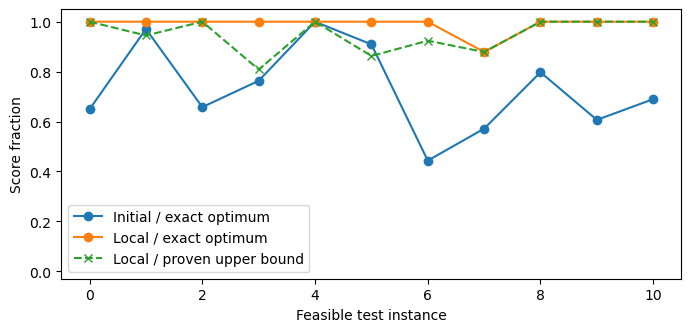

In [38]:
def benchmark_small_instances(n_trials=12, seed=2026):
    rng = random.Random(seed)
    rows = []
    counts = Counter()
    for _ in range(n_trials):
        inst = random_instance(m=7,T=4,max_dept_size=3,availability_fraction=.65,
                               score_prob=.4,seed=rng.randrange(2**63))
        try:
            initial = gcol_feasible_coloring(inst,fallback_timeout=2,seed=seed)
        except InfeasibleInstance:
            counts['proven_infeasible'] += 1; continue
        except TimeoutError:
            counts['unknown_timeout'] += 1; continue
        final,history = local_search(inst,initial,max_rounds=5,pair_component_limit=10)
        _,optimum,n = exact_optimum(inst)
        upper = access_upper_bound(inst)
        F0,F = access_score(inst,initial),access_score(inst,final)
        rows.append({'initial':F0,'final':F,'exact_optimum':optimum,
                     'ratio_initial':F0/optimum if optimum else np.nan,
                     'ratio_final':F/optimum if optimum else np.nan,
                     'certified_fraction':F/upper if upper else np.nan,
                     'feasible_colorings':n})
    return pd.DataFrame(rows),dict(counts)

small_results,small_counts = benchmark_small_instances()
display(small_results)
print(small_counts)
if not small_results.empty:
    fig,ax = plt.subplots(figsize=(8,3.5))
    ax.plot(small_results['ratio_initial'],'o-',label='Initial / exact optimum')
    ax.plot(small_results['ratio_final'],'o-',label='Local / exact optimum')
    ax.plot(small_results['certified_fraction'],'x--',label='Local / proven upper bound')
    ax.set(xlabel='Feasible test instance',ylabel='Score fraction',ylim=(-.03,1.05))
    ax.legend();plt.show()

## 15 . Optional parameter sweep
- Toggle `CONFIG.run_parameter_sweep`.
- Vary availability × desire; shared seeds, failure counts, gains + certificates.

In [39]:
def run_parameter_sweep(base, availability=(.20,.35,.50), desire=(.15,.60), trials=4):
    records = []
    for p in availability:
        for q in desire:
            counts = Counter()
            ratios, gains, observed = [],[],[]
            for trial in range(trials):
                inst = random_instance(m=min(base.courses,24),T=40,max_dept_size=base.max_department_size,
                    teacher_reuse_prob=base.teacher_reuse_probability,availability_fraction=p,
                    desire_probability=q,score_prob=base.external_course_offer_probability,
                    cohort_size=base.cohort_size,external_courses_per_student=base.external_courses_per_student,
                    seed=9000+trial)
                try:initial = gcol_feasible_coloring(inst,fallback_timeout=base.feasibility_timeout,seed=trial)
                except InfeasibleInstance:counts['infeasible']+=1;continue
                except TimeoutError:counts['timeout']+=1;continue
                counts['feasible']+=1
                final,_ = local_search(inst,initial,max_rounds=2,pair_component_limit=6)
                upper = access_upper_bound(inst)
                if upper:ratios.append(access_score(inst,final)/upper)
                gains.append(access_score(inst,final)-access_score(inst,initial))
                observed.append(np.mean([len(inst.professor_availability[p])/40 for p in inst.professors]))
            records.append({'availability_probability':p,'desire_probability':q,'trials':trials,
                'feasible':counts['feasible'],'proven_infeasible':counts['infeasible'],'timeout':counts['timeout'],
                'mean_realized_availability_if_feasible':np.mean(observed) if observed else np.nan,
                'mean_gain_if_feasible':np.mean(gains) if gains else np.nan,
                'mean_certified_fraction_if_feasible':np.mean(ratios) if ratios else np.nan})
    return pd.DataFrame(records)

if CONFIG.run_parameter_sweep:
    display(run_parameter_sweep(CONFIG))


## 16 . Time-only experiment runner
- Fresh feasible instance → local search + repaired SDP proposals → retain best F.
- This intermediate solution does not yet enforce rooms.

In [40]:
def run_fresh_realistic_experiment(config=None):
    config = CONFIG if config is None else config
    inst,initial,generation = generate_weekly(config)
    counts = [len(inst.professor_availability[p]) for p in inst.professors]
    print({'courses':len(inst.classes),'departments':len(inst.departments),'professors':len(inst.professors),
           'requested_availability_probability':config.professor_availability_probability,
           'realized_availability_on_accepted_input':float(np.mean(counts)/40),**generation})
    print_professor_availability(inst)
    print_weekly_timetable(inst,initial,title='Initial feasible timetable')
    start = time.perf_counter()
    baseline,base_history,base_details = local_search(inst,initial,max_rounds=config.local_rounds,
        pair_component_limit=config.pair_component_limit,return_details=True)
    final,history,details = baseline,base_history,base_details
    candidates = [{'method':'GCol/backtracking + local search','start_score':access_score(inst,initial),
                   'final_score':access_score(inst,baseline),'termination':base_details['termination']}]
    newman_info = None
    if config.use_newman and cp is not None and inst.T >= 2 and inst.scores:
        proposals,newman_info = newman_proposals(inst,initial,config,seed=generation['instance_seed'])
        for i,phi in enumerate(proposals):
            out,h,d = local_search(inst,phi,max_rounds=config.local_rounds,
                pair_component_limit=config.pair_component_limit,return_details=True)
            candidates.append({'method':f'Newman repair {i+1} + local search','start_score':access_score(inst,phi),
                               'final_score':access_score(inst,out),'termination':d['termination']})
            if access_score(inst,out) > access_score(inst,final):
                final,history,details = out,h,d
    upper = access_upper_bound(inst)
    F0,F = access_score(inst,initial),access_score(inst,final)
    print({'initial_access_score':F0,'final_access_score':F,'gain':F-F0,
           'proven_combinatorial_upper':upper,'certified_fraction_of_global_optimum':F/upper if upper else None,
           'zero_score_optimum':upper == 0,'seconds':round(time.perf_counter()-start,3),**details})
    if newman_info is not None:
        print(newman_info)
    display(pd.DataFrame(candidates))
    changed = [(c,inst.slot_name(initial[c]),inst.slot_name(final[c])) for c in inst.classes if initial[c] != final[c]]
    display(pd.DataFrame(changed,columns=['Course','Initial slot','Final slot']))
    print_weekly_timetable(inst,final,title='Best timetable after local search')
    plot_weekly_timetable(inst,final,title='Best timetable after local search')
    fig,ax = plt.subplots(figsize=(8,3.5))
    ax.plot(base_history,'o-',label='Initial timetable search')
    if history is not base_history:
        ax.plot(history,'o-',label='Winning repaired proposal search')
    ax.set(xlabel='Accepted improvement within each search',ylabel='Access score F')
    ax.legend();plt.show()
    assert is_feasible(inst,initial) and is_feasible(inst,final)
    assert F+1e-9 >= max(F0,access_score(inst,baseline))
    assert check_score_identity(inst,final) and F <= upper+1e-9
    return {'instance':inst,'initial':initial,'final':final,'history':history,
            'upper':upper,'newman':newman_info,'generation':generation,'candidates':candidates}


## 17 . Rooms + high-school constraints
- Each physical room is listed separately, so a limited number of computer/lab rooms is enforced automatically.
- `RoomData.required_equipment[c]` can require `computers`, `science_lab`, etc.
- `LinkConstraint(a,b,min_gap,max_gap,same_day)` links sessions, e.g. lecture before exercises.
- Professor availability remains the source of allowed times.
- Room changes can be restricted to lunch/break boundaries.


In [41]:
@dataclass
class RoomConfig:
    general_rooms: int = 6
    specialized_rooms: dict = field(default_factory=lambda: {'science_lab': 2, 'computers': 2, 'art': 2})
    availability_probability: float = .90
    specialized_course_probability: float = .30
    subject_reservation_probability: float = 0.0
    enforce_break_changes: bool = True
    allowed_change_boundaries: tuple = (2, 4, 6)
    slots_per_day: int = 8
    seed: int | None = 42
    feasibility_seconds: float = 5.0
    score_seconds: float = 10.0
    stability_seconds: float = 5.0

    def validate(self):
        if not isinstance(self.general_rooms, int) or self.general_rooms < 0:
            raise ValueError('general_rooms must be a nonnegative integer')
        if any(not isinstance(n, int) or n < 0 for n in self.specialized_rooms.values()):
            raise ValueError('Room counts must be nonnegative integers')
        if self.general_rooms + sum(self.specialized_rooms.values()) < 1:
            raise ValueError('At least one room required')
        for name in ['availability_probability', 'specialized_course_probability', 'subject_reservation_probability']:
            if not 0 <= getattr(self, name) <= 1:
                raise ValueError(f'{name} must be in [0,1]')
        if not isinstance(self.slots_per_day, int) or self.slots_per_day < 1:
            raise ValueError('slots_per_day must be positive')
        if any(not isinstance(b, int) or not 0 < b < self.slots_per_day for b in self.allowed_change_boundaries):
            raise ValueError('Boundary b is between blocks b-1 and b within each day')
        if min(self.feasibility_seconds, self.score_seconds, self.stability_seconds) <= 0:
            raise ValueError('Solver time budgets must be positive')
        return self

@dataclass
class RoomData:
    equipment: dict
    available: dict
    allowed_subjects: dict
    subject: dict
    required_equipment: dict

    @property
    def rooms(self):
        return list(self.equipment)

    def validate(self, inst):
        rooms, courses = set(self.rooms), set(inst.classes)
        if not rooms or set(self.available) != rooms or set(self.allowed_subjects) != rooms:
            raise ValueError('Room maps must have identical, nonempty keys')
        if set(self.subject) != courses or set(self.required_equipment) != courses:
            raise ValueError('Specify a subject and equipment requirements for every course')
        if any(not isinstance(t, (int, np.integer)) or not 0 <= t < inst.T for ts in self.available.values() for t in ts):
            raise ValueError('Invalid room availability slot')
        return self

    def compatible(self, c, r):
        subjects = self.allowed_subjects[r]
        return set(self.required_equipment[c]) <= set(self.equipment[r]) and (subjects is None or self.subject[c] in subjects)

    def permits(self, c, t, r):
        return t in self.available[r] and self.compatible(c, r)

ROOM_CONFIG = RoomConfig()


def generate_rooms(inst, config=ROOM_CONFIG):
    config.validate()
    rng = random.Random(config.seed)
    equipment = {f'G{i+1}': set() for i in range(config.general_rooms)}
    for kind, n in config.specialized_rooms.items():
        equipment.update({f'{kind}_{i+1}': {kind} for i in range(n)})
    available = {r: {t for t in range(inst.T) if rng.random() < config.availability_probability} for r in equipment}
    subject = dict(inst.department)
    subjects = inst.departments
    allowed = {r: ({rng.choice(subjects)} if rng.random() < config.subject_reservation_probability else None) for r in equipment}
    kinds = list(config.specialized_rooms)
    required = {c: ({rng.choice(kinds)} if kinds and rng.random() < config.specialized_course_probability else set()) for c in inst.classes}
    return RoomData(equipment, available, allowed, subject, required).validate(inst)


def room_changes(inst, phi, rho, config=ROOM_CONFIG):
    changes = []
    for p in inst.professors:
        days = defaultdict(list)
        for c in inst.classes_of_professor(p):
            days[phi[c] // config.slots_per_day].append(c)
        for day, courses in days.items():
            order = sorted(courses, key=lambda c: phi[c])
            for a, b in zip(order, order[1:]):
                if rho[a] != rho[b]:
                    i, j = phi[a] % config.slots_per_day, phi[b] % config.slots_per_day
                    permitted = any(i < boundary <= j for boundary in config.allowed_change_boundaries)
                    changes.append((p, day, a, b, permitted))
    return changes


def rooms_feasible(inst, phi, rho, data, config=ROOM_CONFIG):
    if not is_feasible(inst, phi) or set(rho) != set(inst.classes):
        return False
    used = set()
    for c in inst.classes:
        r, t = rho[c], phi[c]
        if r not in data.equipment or not data.permits(c, t, r) or (t, r) in used:
            return False
        used.add((t, r))
    return not config.enforce_break_changes or all(x[-1] for x in room_changes(inst, phi, rho, config))


def match_rooms_at_fixed_times(inst, phi, data):
    if not is_feasible(inst, phi):
        raise ValueError('The time assignment must be feasible')
    data.validate(inst)
    rho = {}
    for t in range(inst.T):
        courses = [c for c in inst.classes if phi[c] == t]
        left = [('course', c) for c in courses]
        graph = nx.Graph()
        graph.add_nodes_from(left, bipartite=0)
        graph.add_nodes_from([('room', r) for r in data.rooms], bipartite=1)
        graph.add_edges_from((('course', c), ('room', r)) for c in courses for r in data.rooms if data.permits(c, t, r))
        matching = nx.bipartite.maximum_matching(graph, top_nodes=left)
        if any(node not in matching for node in left):
            return None
        rho.update({c: matching[('course', c)][1] for c in courses})
    return rho


## 18 . Joint time + room search
- Assign each session a `(timeslot, room)` pair.
- Hard constraints: professor, department/cohort, room occupancy, availability, room equipment, and linked-session precedence.
- The search uses MRV backtracking on small instances and a feasible-incumbent/local-search strategy on larger ones.

In [42]:
def _room_domains(inst, data, fixed_times=None):
    domains = {}
    for c in inst.classes:
        ts = [fixed_times[c]] if fixed_times is not None else sorted(inst.allowed_slots(c))
        domains[c] = [(t, r) for t in ts for r in data.rooms if data.permits(c, t, r)]
    return domains


def _room_objective(inst, phi, rho, config, objective):
    score = access_score(inst, phi)
    changes = len(room_changes(inst, phi, rho, config))
    if objective == 'score':
        return (score, -changes)
    if objective == 'stability':
        return (-changes,)
    return (0,)


def _room_local_improve(inst, phi, rho, data, config, objective='score',
                        score_floor=None, score_equal=None, seconds=1.0):
    phi, rho = dict(phi), dict(rho)
    end = time.perf_counter() + max(0.05, seconds)

    def valid_score(p):
        s = access_score(inst, p)
        if score_floor is not None and s + 1e-9 < score_floor:
            return False
        if score_equal is not None and abs(s - score_equal) > 1e-9:
            return False
        return True

    def better(p, r, best_key):
        if not rooms_feasible(inst, p, r, data, config) or not valid_score(p):
            return None
        key = _room_objective(inst, p, r, config, objective)
        return key if key > best_key else None

    changed = True
    while changed and time.perf_counter() < end:
        changed = False
        best_key = _room_objective(inst, phi, rho, config, objective)
        best = None

        for c in inst.classes:
            if time.perf_counter() >= end:
                break
            for t in sorted(inst.allowed_slots(c)):
                for r in data.rooms:
                    if t == phi[c] and r == rho[c]:
                        continue
                    if not data.permits(c, t, r):
                        continue
                    p2, r2 = dict(phi), dict(rho)
                    p2[c], r2[c] = t, r
                    key = better(p2, r2, best_key)
                    if key is not None:
                        best_key, best = key, (p2, r2)

        if best is None:
            for a, b in combinations(inst.classes, 2):
                if time.perf_counter() >= end:
                    break
                p2, r2 = dict(phi), dict(rho)
                p2[a], p2[b] = phi[b], phi[a]
                r2[a], r2[b] = rho[b], rho[a]
                if not data.permits(a, p2[a], r2[a]) or not data.permits(b, p2[b], r2[b]):
                    continue
                key = better(p2, r2, best_key)
                if key is not None:
                    best_key, best = key, (p2, r2)

        if best is not None:
            phi, rho = best
            changed = True
    return phi, rho


def _room_search(inst, data, config, fixed_times=None, hint=None,
                 score_floor=None, score_equal=None, objective='score',
                 seconds=5.0, exhaustive=True):
    domains = _room_domains(inst, data, fixed_times)
    if any(not domains[c] for c in inst.classes):
        return None, True, 0

    end = time.perf_counter() + seconds
    nodes = 0
    timed_out = False
    best = None
    best_key = None

    if hint is not None:
        hp, hr = hint
        if rooms_feasible(inst, hp, hr, data, config):
            if fixed_times is None or all(hp[c] == fixed_times[c] for c in inst.classes):
                s = access_score(inst, hp)
                if (score_floor is None or s + 1e-9 >= score_floor) and (score_equal is None or abs(s-score_equal) <= 1e-9):
                    best = (dict(hp), dict(hr))
                    best_key = _room_objective(inst, hp, hr, config, objective)

    phi, rho = {}, {}
    used_prof, used_dept, used_room = set(), set(), set()

    def rec():
        nonlocal best, best_key, timed_out, nodes
        if time.perf_counter() >= end:
            timed_out = True
            return False
        nodes += 1
        if len(phi) == len(inst.classes):
            if not rooms_feasible(inst, phi, rho, data, config):
                return False
            s = access_score(inst, phi)
            if score_floor is not None and s + 1e-9 < score_floor:
                return False
            if score_equal is not None and abs(s-score_equal) > 1e-9:
                return False
            key = _room_objective(inst, phi, rho, config, objective)
            if best_key is None or key > best_key:
                best, best_key = (dict(phi), dict(rho)), key
            return objective == 'feasibility'

        remaining = [c for c in inst.classes if c not in phi]
        legal = {}
        for c in remaining:
            vals = []
            for t, r in domains[c]:
                if (inst.teacher[c], t) in used_prof or (inst.department[c], t) in used_dept or (r, t) in used_room:
                    continue
                phi[c] = t
                ok = inst.links_ok(phi, partial=True)
                phi.pop(c)
                if ok:
                    vals.append((t, r))
            if not vals:
                return False
            legal[c] = vals

        c = min(remaining, key=lambda z: (len(legal[z]), -len(inst.classes_of_department(inst.department[z]))))
        vals = legal[c]
        if hint is not None:
            hp, hr = hint
            vals = sorted(vals, key=lambda z: (0 if hp.get(c) == z[0] and hr.get(c) == z[1] else 1, z))

        for t, r in vals:
            phi[c], rho[c] = t, r
            used_prof.add((inst.teacher[c], t))
            used_dept.add((inst.department[c], t))
            used_room.add((r, t))
            stop = rec()
            used_prof.remove((inst.teacher[c], t))
            used_dept.remove((inst.department[c], t))
            used_room.remove((r, t))
            phi.pop(c); rho.pop(c)
            if stop and objective == 'feasibility':
                return True
            if timed_out:
                return False
        return False

    rec()
    proven = not timed_out
    return best, proven, nodes


def solve_room_model(inst, data, config=ROOM_CONFIG, seconds=None, fixed_times=None, hint=None,
                     score_floor=None, score_equal=None, objective='score'):
    data.validate(inst)
    if objective not in {'score', 'stability', 'feasibility'}:
        raise ValueError('Unknown objective')
    if fixed_times is not None and not is_feasible(inst, fixed_times):
        return {'status': 'INFEASIBLE', 'seconds': 0.0}

    seconds = seconds or config.score_seconds
    start = time.perf_counter()

    incumbent = None
    if hint is not None:
        hp, hr = hint
        if rooms_feasible(inst, hp, hr, data, config):
            if fixed_times is None or all(hp[c] == fixed_times[c] for c in inst.classes):
                incumbent = (dict(hp), dict(hr))

    # Large instances use a feasible incumbent + room-aware local search.
    if incumbent is not None and len(inst.classes) > 14 and objective != 'feasibility':
        p, r = _room_local_improve(inst, *incumbent, data, config, objective,
                                   score_floor, score_equal, seconds=min(seconds, 2.0))
        return {
            'status': 'FEASIBLE', 'seconds': time.perf_counter()-start,
            'score_upper': access_upper_bound(inst) if objective == 'score' else None,
            'phi': p, 'rho': r, 'score': access_score(inst, p),
            'changes': len(room_changes(inst, p, r, config))
        }

    best, proven, nodes = _room_search(
        inst, data, config, fixed_times=fixed_times, hint=hint,
        score_floor=score_floor, score_equal=score_equal, objective=objective,
        seconds=seconds, exhaustive=(objective != 'feasibility')
    )

    if best is None:
        return {'status': 'INFEASIBLE' if proven else 'UNKNOWN',
                'seconds': time.perf_counter()-start, 'nodes': nodes}

    p, r = best
    if objective != 'feasibility' and len(inst.classes) > 8:
        p, r = _room_local_improve(inst, p, r, data, config, objective,
                                   score_floor, score_equal,
                                   seconds=max(.05, min(1.0, seconds/5)))

    status = 'OPTIMAL' if (objective == 'feasibility' or proven) else 'FEASIBLE'
    score = access_score(inst, p)
    return {
        'status': status, 'seconds': time.perf_counter()-start, 'nodes': nodes,
        'score_upper': score if objective == 'score' and proven else
                       (access_upper_bound(inst) if objective == 'score' else None),
        'phi': p, 'rho': r, 'score': score,
        'changes': len(room_changes(inst, p, r, config))
    }

## 19 . Room-aware improvement
1. Attempts an exact per-slot room matching for the time-only timetable.
2. If room/break constraints fail, search jointly over time and rooms.
3. Improve access score while preserving every hard constraint.
4. At the retained score, reduce professor room changes.


In [43]:
def optimize_with_rooms(inst, phi, data, config=ROOM_CONFIG):
    rho = match_rooms_at_fixed_times(inst, phi, data)
    stages = []
    if rho is not None and rooms_feasible(inst, phi, rho, data, config):
        baseline = {'phi': dict(phi), 'rho': rho, 'score': access_score(inst, phi),
                    'changes': len(room_changes(inst, phi, rho, config)), 'status': 'MATCHED'}
    else:
        baseline = solve_room_model(inst, data, config, fixed_times=phi,
                                   objective='feasibility', seconds=config.feasibility_seconds)
        stages.append({'stage': 'Fixed-time room feasibility', 'status': baseline['status']})
        if 'phi' not in baseline:
            baseline = solve_room_model(inst, data, config, objective='feasibility', seconds=config.feasibility_seconds)
            stages.append({'stage': 'Joint time/room feasibility', 'status': baseline['status']})
            if 'phi' not in baseline:
                return {'status': baseline['status'], 'stages': stages, 'baseline': None, 'best': None}
    best = baseline
    primary = solve_room_model(inst, data, config, score_floor=baseline['score'],
                               hint=(baseline['phi'], baseline['rho']), seconds=config.score_seconds)
    stages.append({'stage': 'Maximize access score', 'status': primary['status']})
    if 'phi' in primary and (primary['score'], -primary['changes']) > (best['score'], -best['changes']):
        best = primary
    upper = access_upper_bound(inst)
    if primary.get('score_upper') is not None:
        upper = min(upper, primary['score_upper'])
    secondary = solve_room_model(inst, data, config, score_equal=best['score'], objective='stability',
                                 hint=(best['phi'], best['rho']), seconds=config.stability_seconds)
    stages.append({'stage': 'Minimize room changes at retained score', 'status': secondary['status']})
    if 'phi' in secondary and secondary['changes'] < best['changes']:
        best = secondary
    assert (best['score'], -best['changes']) >= (baseline['score'], -baseline['changes'])
    assert best['score'] <= upper + 1e-6
    return {'status': 'FEASIBLE', 'baseline': baseline, 'best': best, 'upper': upper,
            'primary_optimal': primary['status'] == 'OPTIMAL',
            'stability_optimal_at_retained_score': secondary['status'] == 'OPTIMAL', 'stages': stages}

## 20 . Room outputs
- Inventory + specialized-course requirements; before/after scores and solver statuses.
- Plot includes room IDs. `room_experiment['assignments']`: course/teacher/slot/room table.
- `room_experiment['data']`: editable room input; pass `data=...` to rerun with actual rooms.

In [44]:
def room_inventory(data):
    return pd.DataFrame([{'Room': r, 'Equipment': ', '.join(sorted(data.equipment[r])) or 'General',
                          'Subjects': '*' if data.allowed_subjects[r] is None else ', '.join(sorted(data.allowed_subjects[r])),
                          'Available slots': len(data.available[r])} for r in data.rooms])


def plot_room_timetable(inst, phi, rho):
    if inst.T != 5 * len(TIME_BLOCKS):
        raise ValueError('Weekly plot uses the example 5-day, 8-period calendar')
    rows = []
    for block in range(len(TIME_BLOCKS)):
        rows.append(['\n\n'.join(f'{c} . {rho[c]}\n{inst.teacher[c]}'
                     for c in sorted(inst.classes) if phi[c] == len(TIME_BLOCKS)*day+block) for day in range(5)])
    heights = [max(.8, .15 * max(s.count('\n')+1 for s in row) + .3) for row in rows]
    fig, ax = plt.subplots(figsize=(17, sum(heights)+1.3))
    ax.axis('off')
    table = ax.table(cellText=rows, rowLabels=[f'{a}–{b}' for a,b in TIME_BLOCKS], colLabels=WEEKDAYS,
                     cellLoc='center', bbox=[.04,.02,.96,.91])
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    for (row, col), cell in table.get_celld().items():
        cell.set_height((.45 if row == 0 else heights[row-1])/(sum(heights)+.45))
        cell.set_edgecolor('#ced8e0')
        cell.set_facecolor('#e3eef4' if row == 0 or col == -1 else ('#f7fafc' if row % 2 else 'white'))
    ax.set_title('Room-feasible timetable . course / room / teacher', pad=12)
    plt.show()


def run_room_experiment(experiment, config=ROOM_CONFIG, data=None):
    inst = experiment['instance']
    data = generate_rooms(inst, config) if data is None else data.validate(inst)
    display(room_inventory(data))
    display(pd.DataFrame([{'Course': c, 'Subject': data.subject[c],
                          'Required equipment': ', '.join(sorted(data.required_equipment[c])) or 'None'}
                         for c in inst.classes if data.required_equipment[c]]))
    result = optimize_with_rooms(inst, experiment['final'], data, config)
    result['data'] = data
    display(pd.DataFrame(result['stages']))
    if result['best'] is None:
        print('Room model:', result['status'], '(INFEASIBLE = proved; UNKNOWN = budget exhausted, unresolved).')
        return result
    initial, best = result['baseline'], result['best']
    display(pd.DataFrame([
        {'Stage': 'Time-only solution (rooms unchecked)', 'Access score': access_score(inst, experiment['final']), 'Room changes': None},
        {'Stage': 'Room-feasible baseline', 'Access score': initial['score'], 'Room changes': initial['changes']},
        {'Stage': 'After room-aware optimization', 'Access score': best['score'], 'Room changes': best['changes']},
    ]))
    print({'room_constrained_score_upper': result['upper'],
           'guaranteed_fraction_of_room_optimum': best['score']/result['upper'] if result['upper'] else None,
           'primary_optimal': result['primary_optimal'],
           'stability_optimal_at_retained_score': result['stability_optimal_at_retained_score'],
           'room_feasibility_verified': rooms_feasible(inst, best['phi'], best['rho'], data, config)})
    plot_room_timetable(inst, best['phi'], best['rho'])
    result['assignments'] = pd.DataFrame([{'Course': c, 'Teacher': inst.teacher[c], 'Slot': inst.slot_name(best['phi'][c]),
                                         'Room': best['rho'][c]} for c in inst.classes])
    return result


## 21 . Room correctness tests


In [45]:
def brute_room_optimum(inst, data, config):
    best, count = None, 0
    for phi in enumerate_feasible_colorings(inst):
        choices = [[r for r in data.rooms if data.permits(c, phi[c], r)] for c in inst.classes]
        for rooms in product(*choices):
            rho = dict(zip(inst.classes, rooms))
            if rooms_feasible(inst, phi, rho, data, config):
                count += 1
                value = (access_score(inst, phi), -len(room_changes(inst, phi, rho, config)))
                if best is None or value > best:
                    best = value
    return best, count


def run_room_tests(trials=12):
    cfg = replace(ROOM_CONFIG, feasibility_seconds=3, score_seconds=3, stability_seconds=3)
    counts = Counter()
    for seed in range(trials):
        rng = random.Random(seed)
        inst = TimetableInstance(4, {0:'A',1:'A',2:'B'}, {0:'P',1:'P',2:'Q'},
            {'P': {t for t in range(4) if rng.random()<.85}, 'Q': {t for t in range(4) if rng.random()<.85}},
            {('A',2): rng.randrange(1,5), ('B',0): 2, ('B',1): 1})
        data = RoomData({'R':set(), 'Lab':{'lab'}},
            {r:{t for t in range(4) if rng.random()<.8} for r in ['R','Lab']},
            {'R':None,'Lab':{'B'} if seed%3==0 else None},
            dict(inst.department), {0:set(),1:{'lab'} if seed%2 else set(),2:set()})
        best, count = brute_room_optimum(inst, data, cfg)
        counts['enumerated_room_feasible_assignments'] += count
        solved = solve_room_model(inst, data, cfg, seconds=3)
        if best is None:
            assert solved['status'] == 'INFEASIBLE'
            counts['proven_infeasible'] += 1
        else:
            assert solved['status'] == 'OPTIMAL' and solved['score'] == best[0]
            stable = solve_room_model(inst, data, cfg, score_equal=solved['score'], objective='stability', seconds=3)
            assert stable['status'] == 'OPTIMAL' and (stable['score'], -stable['changes']) == best
            counts['exact_optimum_matches'] += 1
        for phi in enumerate_feasible_colorings(inst):
            match = match_rooms_at_fixed_times(inst, phi, data)
            relaxed = replace(cfg, enforce_break_changes=False)
            exists = any(rooms_feasible(inst, phi, dict(zip(inst.classes, rr)), data, relaxed)
                         for rr in product(data.rooms, repeat=len(inst.classes)))
            assert (match is not None) == exists
            if match is not None:
                assert rooms_feasible(inst, phi, match, data, relaxed)
            counts['fixed_time_matching_checks'] += 1
    inst = TimetableInstance(2, {0:'A',1:'B'}, {0:'P',1:'Q'}, {'P':{0,1},'Q':{0,1}}, {('A',1):3})
    data = RoomData({'Lab':{'lab'}}, {'Lab':{0,1}}, {'Lab':None}, dict(inst.department), {0:{'lab'},1:{'lab'}})
    initial = {0:0,1:0}
    assert match_rooms_at_fixed_times(inst, initial, data) is None
    repaired = optimize_with_rooms(inst, initial, data, cfg)
    assert repaired['best'] is not None and repaired['best']['score'] == 3
    assert repaired['best']['phi'][0] != repaired['best']['phi'][1]
    impossible = TimetableInstance(1, dict(inst.department), dict(inst.teacher), {'P':{0},'Q':{0}}, dict(inst.scores))
    closed = RoomData(data.equipment, {'Lab':{0}}, data.allowed_subjects, data.subject, data.required_equipment)
    assert solve_room_model(impossible, closed, cfg)['status'] == 'INFEASIBLE'
    for j, allowed in [(1,False),(2,True),(3,True)]:
        inst = TimetableInstance(4,{0:'A',1:'B'},{0:'P',1:'P'},{'P':{0,j}}, {})
        data = RoomData({'X':{'x'},'Y':{'y'}}, {'X':{0},'Y':{j}}, {'X':None,'Y':None},
                        dict(inst.department), {0:{'x'},1:{'y'}})
        phi, rho = {0:0,1:j}, {0:'X',1:'Y'}
        assert rooms_feasible(inst,phi,rho,data,cfg) == allowed
        s = solve_room_model(inst,data,cfg,fixed_times=phi)
        assert (s['status']=='OPTIMAL') == allowed
        if allowed:
            assert s['changes'] == 1

    linked = TimetableInstance(
        6,
        {'CSL':'CS','CSE':'CS'},
        {'CSL':'PL','CSE':'PE'},
        {'PL':{0,1,3}, 'PE':{1,2,4}},
        {},
        links=(LinkConstraint('CSL','CSE',1,2,True),),
        slots_per_day=3
    )
    linked_rooms = RoomData(
        {'R':set(),'PC':{'computers'}},
        {'R':set(range(6)),'PC':set(range(6))},
        {'R':None,'PC':None},
        {'CSL':'CS','CSE':'CS'},
        {'CSL':set(),'CSE':{'computers'}}
    )
    lr = solve_room_model(linked, linked_rooms, replace(cfg, slots_per_day=3), seconds=3)
    assert 'phi' in lr and linked.links_ok(lr['phi']) and lr['rho']['CSE'] == 'PC'
    counts['linked_equipment_checks'] = 1
    counts['targeted_checks'] = 5
    return dict(counts)

room_test_results = run_room_tests()
print('PASS: room assignments, exact score/stability, matching, joint repair, infeasibility, break policy')
print(room_test_results)


PASS: room assignments, exact score/stability, matching, joint repair, infeasibility, break policy
{'enumerated_room_feasible_assignments': 399, 'exact_optimum_matches': 10, 'fixed_time_matching_checks': 410, 'proven_infeasible': 2, 'linked_equipment_checks': 1, 'targeted_checks': 5}


## 22 . CSV input / output

A single CSV can contain several record types. IDs for courses, professors and rooms must be unique.

| `kind` | Required fields | Meaning |
|---|---|---|
| `course` | `id, department, professor` | One class/session. `subject` is optional; `required_equipment` is `;`-separated. |
| `professor` | `id, available_slots` | Slot indices such as `0;1;8;9`. Slots `0..7` are Monday, `8..15` Tuesday, etc. Blank/`*`/`all` = all slots; `none`/`-` = no slots. |
| `room` | `id, available_slots` | One physical room. `equipment` and `allowed_subjects` are `;`-separated. Blank/`*` subjects = unrestricted. |
| `reward` | `department, target_course, weight` | Optional cross-department access reward. |
| `link` | `from_course, to_course` | Requires `from_course` before `to_course`. Optional `min_gap`, `max_gap`, `same_day`. |

In [46]:
def _parts(value):
    if pd.isna(value) or str(value).strip() in {'', '*'}:
        return []
    return [x.strip() for x in str(value).split(';') if x.strip()]


def _slots(value, T):
    s = '' if pd.isna(value) else str(value).strip().lower()
    if s in {'', '*', 'all'}:
        return set(range(T))
    if s in {'none', '-', 'empty'}:
        return set()
    out = {int(x.strip()) for x in s.split(';') if x.strip()}
    if any(t < 0 or t >= T for t in out):
        raise ValueError(f'Availability slots must lie in 0..{T-1}')
    return out


def _bool(value):
    return str(value).strip().lower() in {'1', 'true', 'yes', 'y'}


def _unique_ids(df, kind):
    ids = [x.strip() for x in df.loc[df['kind'] == kind, 'id'].astype(str)]
    if any(not x for x in ids):
        raise ValueError(f'{kind} rows require a nonempty id')
    dup = pd.Series(ids)[pd.Series(ids).duplicated()].unique().tolist()
    if dup:
        raise ValueError(f'Duplicate {kind} id(s): {", ".join(map(str, dup))}')


def load_constraints_csv(path, T=40, slot_labels=None, slots_per_day=8):
    df = pd.read_csv(path, dtype=str).fillna('')
    if 'kind' not in df.columns:
        raise ValueError("Input CSV needs a 'kind' column")
    if 'id' not in df.columns:
        df['id'] = ''
    df['kind'] = df['kind'].str.strip().str.lower()
    known = {'course','professor','room','reward','link',''}
    unknown = sorted(set(df['kind']) - known)
    if unknown:
        raise ValueError(f'Unknown row kind(s): {unknown}')
    for k in ['course','professor','room']:
        _unique_ids(df, k)

    courses = df[df['kind'] == 'course']
    if courses.empty:
        raise ValueError('At least one course row is required')
    department = {r['id'].strip(): r.get('department','').strip() for _,r in courses.iterrows()}
    teacher = {r['id'].strip(): r.get('professor','').strip() for _,r in courses.iterrows()}
    if any(not d for d in department.values()) or any(not p for p in teacher.values()):
        raise ValueError('Every course needs a department and professor')

    prof_rows = df[df['kind'] == 'professor']
    prof_avail = {r['id'].strip(): _slots(r.get('available_slots', ''), T)
                  for _, r in prof_rows.iterrows()}
    for p in set(teacher.values()):
        prof_avail.setdefault(p, set(range(T)))

    scores = {}
    for _, r in df[df['kind'] == 'reward'].iterrows():
        key = (r.get('department','').strip(), r.get('target_course','').strip())
        if key in scores:
            raise ValueError(f'Duplicate reward row for {key}')
        scores[key] = float(r.get('weight',''))

    links = []
    for _, r in df[df['kind'] == 'link'].iterrows():
        max_gap = r.get('max_gap', '').strip()
        links.append(LinkConstraint(
            r.get('from_course','').strip(), r.get('to_course','').strip(),
            int(r.get('min_gap', '') or 1),
            int(max_gap) if max_gap else None,
            _bool(r.get('same_day', ''))
        ))

    inst = TimetableInstance(
        T, department, teacher, prof_avail, scores,
        slot_labels=slot_labels, links=tuple(links), slots_per_day=slots_per_day
    )

    subject = {}
    required = {}
    for _, r in courses.iterrows():
        c = r['id'].strip()
        subject[c] = r.get('subject', '').strip() or department[c]
        required[c] = set(_parts(r.get('required_equipment', '')))

    room_rows = df[df['kind'] == 'room']
    if room_rows.empty:
        raise ValueError('At least one room row is required')
    equipment, available, allowed = {}, {}, {}
    for _, r in room_rows.iterrows():
        room = r['id'].strip()
        equipment[room] = set(_parts(r.get('equipment', '')))
        available[room] = _slots(r.get('available_slots', ''), T)
        a = _parts(r.get('allowed_subjects', ''))
        allowed[room] = set(a) if a else None

    data = RoomData(equipment, available, allowed, subject, required).validate(inst)
    return inst, data


def save_timetable_csv(inst, phi, rho, path):
    rows = []
    for t in range(inst.T):
        triples = sorted(
            (str(inst.teacher[c]), str(c), str(rho[c]))
            for c in inst.classes if phi[c] == t
        )
        rows.append({
            'slot_index': t,
            'timeslot': inst.slot_name(t),
            'assignments': '; '.join(f'({p},{c},{r})' for p,c,r in triples)
        })
    out = pd.DataFrame(rows)
    out.to_csv(path, index=False)
    return out


def write_constraints_example(path='timetable_constraints_example.csv'):
    cols = ['kind','id','department','professor','subject','available_slots',
            'equipment','allowed_subjects','required_equipment','target_course',
            'weight','from_course','to_course','min_gap','max_gap','same_day']
    rows = [
        dict(kind='course', id='CS142L', department='CS', professor='P01', subject='CS142'),
        dict(kind='course', id='CS142E', department='CS', professor='P02', subject='CS142', required_equipment='computers'),
        dict(kind='course', id='MA101', department='MA', professor='P03', subject='MA101'),
        dict(kind='professor', id='P01', available_slots='0;1;2;4;5;8;9;10;12;13;16;17;18;20;21;24;25;28;29;32;33;36;37'),
        dict(kind='professor', id='P02', available_slots='1;2;3;5;6;9;10;11;13;14;17;18;19;21;22;25;26;29;30;33;34;37;38'),
        dict(kind='professor', id='P03', available_slots='0;2;4;6;8;10;12;14;16;18;20;22;24;26;28;30;32;34;36;38'),
        dict(kind='room', id='R101', available_slots='*', equipment='', allowed_subjects='*'),
        dict(kind='room', id='PC1', available_slots='*', equipment='computers', allowed_subjects='*'),
        dict(kind='room', id='PC2', available_slots='*', equipment='computers', allowed_subjects='*'),
        dict(kind='link', from_course='CS142L', to_course='CS142E', min_gap='1', max_gap='6', same_day='true'),
        dict(kind='reward', department='MA', target_course='CS142L', weight='5'),
    ]
    pd.DataFrame(rows, columns=cols).fillna('').to_csv(path, index=False)
    return Path(path)


def solve_constraints_csv(input_path, output_path='timetable_output.csv',
                          config=ROOM_CONFIG, T=40, slot_labels=None, slots_per_day=8):
    inst, data = load_constraints_csv(
        input_path, T=T,
        slot_labels=weekly_slot_labels() if slot_labels is None and T == 40 and slots_per_day == 8 else slot_labels,
        slots_per_day=slots_per_day
    )
    try:
        phi = gcol_feasible_coloring(
            inst,
            fallback_timeout=max(config.feasibility_seconds, 2.0),
            return_info=False
        )
        result = optimize_with_rooms(inst, phi, data, config)
    except (InfeasibleInstance, TimeoutError):
        first = solve_room_model(
            inst, data, config,
            objective='feasibility',
            seconds=config.feasibility_seconds
        )
        if 'phi' not in first:
            return {'instance': inst, 'data': data, 'status': first['status'], 'best': None}
        result = optimize_with_rooms(inst, first['phi'], data, config)

    result['instance'] = inst
    result['data'] = data
    if result.get('best') is not None:
        save_timetable_csv(inst, result['best']['phi'], result['best']['rho'], output_path)
    return result


## 23 . Run / rerun

{'courses': 40, 'departments': 9, 'professors': 31, 'requested_availability_probability': 0.25, 'realized_availability_on_accepted_input': 0.2411290322580645, 'attempts': 1, 'run_seed': 3603483205301812197, 'instance_seed': 2390154724929477875, 'solver': 'GCol DSATUR + bounded local search'}
 P01: Tuesday 10:00–11:00, Tuesday 11:00–12:00, Wednesday 13:00–14:00, Thursday 14:00–15:00, Friday 09:00–10:00, Friday 16:00–17:00
 P02: Tuesday 08:00–09:00, Wednesday 08:00–09:00, Wednesday 09:00–10:00, Wednesday 11:00–12:00, Wednesday 14:00–15:00, Thursday 11:00–12:00, Thursday 13:00–14:00, Thursday 16:00–17:00, Friday 09:00–10:00, Friday 10:00–11:00, Friday 13:00–14:00, Friday 16:00–17:00
 P03: Monday 09:00–10:00, Monday 11:00–12:00, Monday 13:00–14:00, Monday 15:00–16:00, Tuesday 15:00–16:00, Wednesday 08:00–09:00, Wednesday 09:00–10:00, Thursday 10:00–11:00, Friday 11:00–12:00, Friday 13:00–14:00, Friday 15:00–16:00, Friday 16:00–17:00
 P04: Monday 08:00–09:00, Monday 11:00–12:00, Monday 14:0

### Initial feasible timetable
| Time | Monday | Tuesday | Wednesday | Thursday | Friday |
|---|---|---|---|---|---|
| **08:00–09:00** | **ST196**<br>P16 | **EC343**<br>P13 | **ST231**<br>P05 | **PH458**<br>P07 | **CH378**<br>P26 |
| **09:00–10:00** | **EC626**<br>P16 | **PH303**<br>P08 | **CS230**<br>P02 | **CH880**<br>P24 | **ST147**<br>P30 |
| **10:00–11:00** | **CH651**<br>P25 | **CS998**<br>P01 | **PH432**<br>P10 | **EC650**<br>P15 | **PH481**<br>P06 |
| **11:00–12:00** | **ST838**<br>P23 | **BI492**<br>P28 | **EC550**<br>P18 | **EC534**<br>P02 | **CS824**<br>P03 |
| **13:00–14:00** | **ST909**<br>P29 | **PH952**<br>P11 | **MA528**<br>P04 | **DS639**<br>P05 | **CS959**<br>P02 |
| **14:00–15:00** | **PH617**<br>P12 | **BI888**<br>P27<br><br>**MA403**<br>P04 | **DS302**<br>P19 | **ST933**<br>P11 | **EE806**<br>P22 |
| **15:00–16:00** | **EC250**<br>P17 | **PH741**<br>P05 | **EC432**<br>P18 | **EC771**<br>P14 | **DS986**<br>P21 |
| **16:00–17:00** | **ST666**<br>P31 | **PH816**<br>P09 | **DS107**<br>P20 | — | **EE840**<br>P23 |

{'initial_access_score': 386.0, 'final_access_score': 386.0, 'gain': 0.0, 'proven_combinatorial_upper': 386.0, 'certified_fraction_of_global_optimum': 1.0, 'zero_score_optimum': False, 'seconds': 2.437, 'termination': 'department/relocation/swap/two-slot local optimum', 'skipped_slot_pairs_at_stop': 0}
{'paper_ratio_for_unconstrained_cut': 0.9759888695865144, 'SDP_status': 'optimal', 'SDP_primal': 1810.9999992708113, 'numerical_cut_upper': 1811.0, 'SDP_gap': 7.291887413884979e-07, 'expected_raw_cut': 1767.5158427927918, 'best_raw_cut': 1806.0, 'raw_cut_violations_after_label_alignment': {'hard_conflicts': 3, 'availability_violations': 3}, 'repair_attempts': 3, 'repair_timeouts': 0, 'numerical_access_upper_from_SDP': 386.0, 'guarantee_scope': 'Unconstrained optional-edge cut only; no inherited ratio after feasibility repair.'}


,method,start_score,final_score,termination
0,GCol/backtracking + local search,386.0,386.0,department/relocation/swap/two-slot local optimum
1,Newman repair 1 + local search,371.0,386.0,department/relocation/swap/two-slot local optimum
2,Newman repair 2 + local search,370.0,386.0,department/relocation/swap/two-slot local optimum
3,Newman repair 3 + local search,378.0,386.0,department/relocation/swap/two-slot local optimum


,Course,Initial slot,Final slot


### Best timetable after local search
| Time | Monday | Tuesday | Wednesday | Thursday | Friday |
|---|---|---|---|---|---|
| **08:00–09:00** | **ST196**<br>P16 | **EC343**<br>P13 | **ST231**<br>P05 | **PH458**<br>P07 | **CH378**<br>P26 |
| **09:00–10:00** | **EC626**<br>P16 | **PH303**<br>P08 | **CS230**<br>P02 | **CH880**<br>P24 | **ST147**<br>P30 |
| **10:00–11:00** | **CH651**<br>P25 | **CS998**<br>P01 | **PH432**<br>P10 | **EC650**<br>P15 | **PH481**<br>P06 |
| **11:00–12:00** | **ST838**<br>P23 | **BI492**<br>P28 | **EC550**<br>P18 | **EC534**<br>P02 | **CS824**<br>P03 |
| **13:00–14:00** | **ST909**<br>P29 | **PH952**<br>P11 | **MA528**<br>P04 | **DS639**<br>P05 | **CS959**<br>P02 |
| **14:00–15:00** | **PH617**<br>P12 | **BI888**<br>P27<br><br>**MA403**<br>P04 | **DS302**<br>P19 | **ST933**<br>P11 | **EE806**<br>P22 |
| **15:00–16:00** | **EC250**<br>P17 | **PH741**<br>P05 | **EC432**<br>P18 | **EC771**<br>P14 | **DS986**<br>P21 |
| **16:00–17:00** | **ST666**<br>P31 | **PH816**<br>P09 | **DS107**<br>P20 | — | **EE840**<br>P23 |

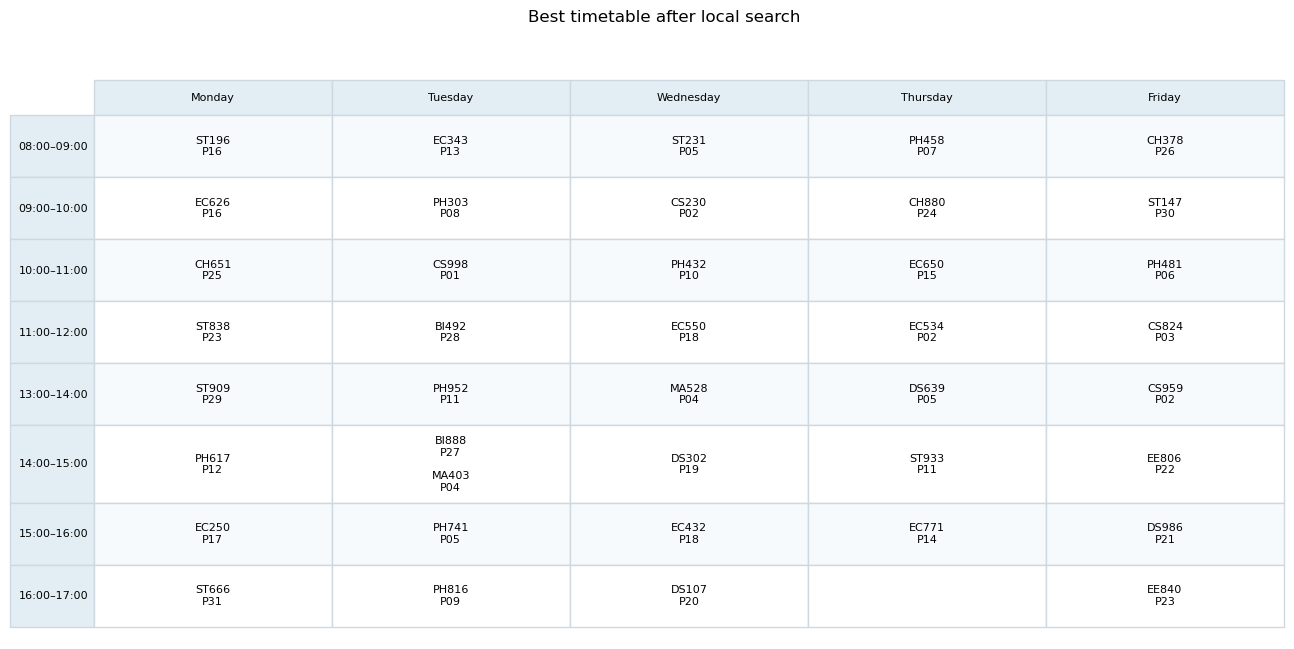

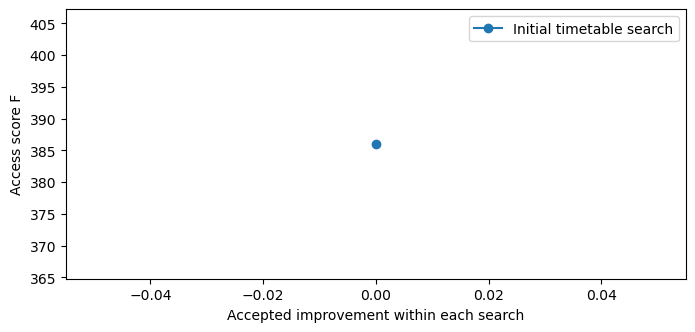

,Room,Equipment,Subjects,Available slots
0,G1,General,*,38
1,G2,General,*,36
2,G3,General,*,35
3,G4,General,*,37
4,G5,General,*,35
5,G6,General,*,33
6,science_lab_1,science_lab,*,34
7,science_lab_2,science_lab,*,37
8,computers_1,computers,*,33
9,computers_2,computers,*,37


,Course,Subject,Required equipment
0,CS959,CS,computers
1,PH952,PH,computers
2,PH617,PH,computers
3,EC534,EC,computers
4,EC771,EC,computers
5,EC250,EC,computers
6,EC550,EC,science_lab
7,DS639,DS,computers
8,DS107,DS,science_lab
9,CH651,CH,science_lab


,stage,status
0,Fixed-time room feasibility,INFEASIBLE
1,Joint time/room feasibility,UNKNOWN


Room model: UNKNOWN (INFEASIBLE = proved; UNKNOWN = budget exhausted, unresolved).


In [47]:
experiment = run_fresh_realistic_experiment(CONFIG)
room_experiment = run_room_experiment(experiment, ROOM_CONFIG)

if room_experiment.get('best') is not None:
    save_timetable_csv(
        experiment['instance'],
        room_experiment['best']['phi'],
        room_experiment['best']['rho'],
        'timetable_output.csv'
    )
    print('Wrote timetable_output.csv')
